# Log-posterior geometry for the 3-state inference model

This notebook keeps the algebra in the original 3D log-probability space. The only quotient operation is the projection along the common-offset axis `(1, 1, 1)`, since adding the same constant to every log-posterior coordinate does not change posterior odds.

## Parameters

Edit this cell first. The default likelihood follows the structure used in `Testing again 0413.ipynb`, with `Scratch` taking the role of the second sickness signal.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

# States and signals
STATES = ["Healthy", "Sickness 1", "Sickness 2"]
SIGNALS = ["Whistle", "Cough", "Scratch"]

# Default likelihood parameters.
# Columns are states: Healthy, Sickness 1, Sickness 2.
# Rows are signals: Whistle, Cough, Scratch.
p_sick_marker = 0.40 #0.40         # P(Cough | Sickness 1) and P(Scratch | Sickness 2)
p_sick_cross = 1./3 # 1 / 3         # P(Scratch | Sickness 1) and P(Cough | Sickness 2)
p_healthy_nonwhistle = 0.15  # P(Cough | Healthy) and P(Scratch | Healthy)

# Parameters for later simulations. They are not needed for the deterministic delta plot below.
ALPHA = 0.90   # exponential discount factor
SIGMA = 0.50   # standard deviation of additive noise in log-likelihood space
T = 100
RANDOM_SEED = 42

# Uniform prior.
prior = np.ones(3) / 3

# Set this to True if you want to specify the full likelihood matrix directly.
USE_CUSTOM_LIKELIHOOD = False
CUSTOM_L = np.array([
    [0.70, 0.2667, 0.2667],  # Whistle
    [0.15, 0.4000, 0.3333],  # Cough
    [0.15, 0.3333, 0.4000],  # Scratch
])

if USE_CUSTOM_LIKELIHOOD:
    L = np.asarray(CUSTOM_L, dtype=float)
else:
    L = np.array([
        [1 - 2 * p_healthy_nonwhistle, 1 - p_sick_marker - p_sick_cross, 1 - p_sick_marker - p_sick_cross],
        [p_healthy_nonwhistle, p_sick_marker, p_sick_cross],
        [p_healthy_nonwhistle, p_sick_cross, p_sick_marker],
    ], dtype=float)

assert L.shape == (3, 3), "L must be a 3 x 3 matrix with rows=signals and columns=states."
assert np.all(L > 0), "All likelihood entries must be strictly positive because we take logs."
assert np.allclose(L.sum(axis=0), 1.0), "Each state column of L must sum to 1."

print("Prior p(s):")
for state, p in zip(STATES, prior):
    print(f"  {state:>10}: {p:.4f}")

print("\nLikelihood matrix L[x, s] = P(x | s):")
print("            " + "  ".join(f"{state:>10}" for state in STATES))
for signal, row in zip(SIGNALS, L):
    print(f"{signal:>10}  " + "  ".join(f"{value:10.4f}" for value in row))


Prior p(s):
     Healthy: 0.3333
  Sickness 1: 0.3333
  Sickness 2: 0.3333

Likelihood matrix L[x, s] = P(x | s):
               Healthy  Sickness 1  Sickness 2
   Whistle      0.7000      0.2667      0.2667
     Cough      0.1500      0.4000      0.3333
   Scratch      0.1500      0.3333      0.4000


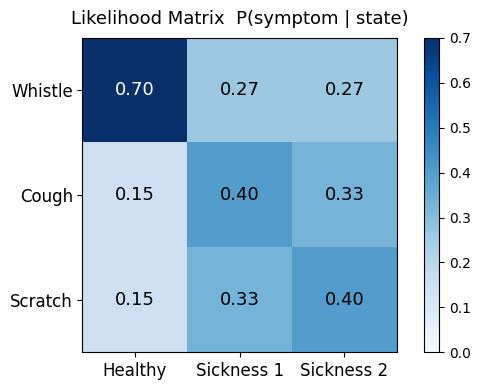

In [2]:
# ── Likelihood heatmap ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(L, vmin=0, vmax=0.7, cmap='Blues')
ax.set_xticks(range(3)); ax.set_xticklabels(STATES, fontsize=12)
ax.set_yticks(range(3)); ax.set_yticklabels(SIGNALS, fontsize=12)
ax.set_title('Likelihood Matrix  P(symptom | state)', fontsize=13, pad=10)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{L[i,j]:.2f}', ha='center', va='center',
                fontsize=13, color='black' if L[i,j] < 0.45 else 'white')
plt.colorbar(im, ax=ax, fraction=0.03)
plt.tight_layout()
plt.show()

## Bayes' rule is linear before normalization

Index states by `i = 1, 2, 3`. For each signal `x`, define the likelihood vector

$$
\ell_x = \big(P(x \mid s_1), P(x \mid s_2), P(x \mid s_3)\big),
\qquad
\delta_x = \log \ell_x.
$$

The posterior update after seeing `x_t` is

$$
p_t(s_i) = \frac{p_{t-1}(s_i) P(x_t \mid s_i)}{\sum_j p_{t-1}(s_j) P(x_t \mid s_j)}.
$$

Let `Lambda_t = log p_t` componentwise. Then

$$
\Lambda_t
= \Lambda_{t-1} + \delta_{x_t}
- c_t {\bf 1},
\qquad
c_t = \log \sum_j \exp\{\Lambda_{t-1,j} + \delta_{x_t,j}\},
$$

where `${\bf 1}=(1,1,1)`. Thus the nonlinear part of Bayes' rule is only the subtraction of a common constant. In the quotient space modulo common offsets, the update is the linear displacement

$$
\Lambda_t \equiv \Lambda_{t-1} + \delta_{x_t}
\quad \text{mod } \mathrm{span}\{(1,1,1)\}.
$$

With the uniform prior, `Lambda_0 = -log(3) * (1, 1, 1)`, so the projected initial point is the origin.

## Projection along the common-offset axis

The projection that removes the irrelevant common log-offset is

$$
\Pi v = v - \bar v {\bf 1},
\qquad
\bar v = \frac{1}{3}\sum_i v_i,
\qquad
\Pi = I - \frac{1}{3}{\bf 1}{\bf 1}^\top.
$$

All posterior odds live in this projected plane, but the objects are still represented as 3-component vectors. For example, for any two states `i` and `j`,

$$
\Lambda_{t,i} - \Lambda_{t,j}
$$

is unchanged by adding any multiple of `(1,1,1)` to `Lambda_t`.

## Signal displacements and expected displacements

The three signal displacements are simply

$$
\delta_x = \big(\log P(x \mid \text{Healthy}),
\log P(x \mid \text{Sickness 1}),
\log P(x \mid \text{Sickness 2})\big).
$$

For a fixed true state `s`, the expected one-step log-likelihood displacement is

$$
\Delta_s = \mathbb{E}[\delta_x \mid s]
= \sum_x P(x \mid s)\,\delta_x.
$$

Its `j`th component is

$$
(\Delta_s)_j = \sum_x P(x \mid s) \log P(x \mid s_j),
$$

the negative cross-entropy between the signal distribution generated by `s` and the signal distribution predicted by hypothesis `s_j`. Therefore

$$
(\Delta_s)_s - (\Delta_s)_j
= D_{KL}\left(P(\cdot \mid s)\,\Vert\,P(\cdot \mid s_j)\right).
$$

So, in expectation, the log-posterior odds drift toward the true state, with strength given by KL separations between the signal distributions.

In [3]:
one = np.ones(3)
Pi = np.eye(3) - np.outer(one, one) / 3

def project_common_offset(v):
    """Remove the component parallel to (1, 1, 1), row by row."""
    v = np.asarray(v, dtype=float)
    return v - v.mean(axis=-1, keepdims=True)

delta = np.log(L)          # rows are delta_x vectors
delta_proj = project_common_offset(delta)

Delta = L.T @ delta        # rows are Delta_s vectors
Delta_proj = project_common_offset(Delta)

KL = np.zeros((3, 3))
for s in range(3):
    for j in range(3):
        KL[s, j] = np.sum(L[:, s] * (np.log(L[:, s]) - np.log(L[:, j])))

print("Projection matrix Pi:")
print(Pi)

print("\nSignal displacements delta_x = log P(x | s):")
print("            " + "  ".join(f"{state:>10}" for state in STATES))
for signal, row in zip(SIGNALS, delta):
    print(f"{signal:>10}  " + "  ".join(f"{value:10.4f}" for value in row))

print("\nProjected signal displacements Pi delta_x:")
print("            " + "  ".join(f"{state:>10}" for state in STATES))
for signal, row in zip(SIGNALS, delta_proj):
    print(f"{signal:>10}  " + "  ".join(f"{value:10.4f}" for value in row))

print("\nExpected displacements Delta_s = E[delta_x | s]:")
print("            " + "  ".join(f"{state:>10}" for state in STATES))
for state, row in zip(STATES, Delta):
    print(f"{state:>10}  " + "  ".join(f"{value:10.4f}" for value in row))

print("\nProjected expected displacements Pi Delta_s:")
print("            " + "  ".join(f"{state:>10}" for state in STATES))
for state, row in zip(STATES, Delta_proj):
    print(f"{state:>10}  " + "  ".join(f"{value:10.4f}" for value in row))

print("\nPairwise KL divergences D_KL(P(.|row state) || P(.|column state)):")
print("            " + "  ".join(f"{state:>10}" for state in STATES))
for state, row in zip(STATES, KL):
    print(f"{state:>10}  " + "  ".join(f"{value:10.4f}" for value in row))


Projection matrix Pi:
[[ 0.6667 -0.3333 -0.3333]
 [-0.3333  0.6667 -0.3333]
 [-0.3333 -0.3333  0.6667]]

Signal displacements delta_x = log P(x | s):
               Healthy  Sickness 1  Sickness 2
   Whistle     -0.3567     -1.3218     -1.3218
     Cough     -1.8971     -0.9163     -1.0986
   Scratch     -1.8971     -1.0986     -0.9163

Projected signal displacements Pi delta_x:
               Healthy  Sickness 1  Sickness 2
   Whistle      0.6434     -0.3217     -0.3217
     Cough     -0.5931      0.3877      0.2054
   Scratch     -0.5931      0.2054      0.3877

Expected displacements Delta_s = E[delta_x | s]:
               Healthy  Sickness 1  Sickness 2
   Healthy     -0.8188     -1.2275     -1.2275
Sickness 1     -1.4863     -1.0852     -1.0973
Sickness 2     -1.4863     -1.0973     -1.0852

Projected expected displacements Pi Delta_s:
               Healthy  Sickness 1  Sickness 2
   Healthy      0.2724     -0.1362     -0.1362
Sickness 1     -0.2634      0.1378      0.1256
Sickn

## Discounting and noise in the same geometry

For later simulations, it is useful to write the projected log-posterior as `Y_t = Pi Lambda_t`. With no discounting and no noise,

$$
Y_t = Y_{t-1} + \Pi\delta_{x_t}.
$$

With exponential discounting, the accumulated evidence can be written

$$
Y_t = \alpha Y_{t-1} + \Pi\delta_{x_t},
$$

because the projected uniform prior is zero and the normalization constant vanishes under `Pi`. With additive log-likelihood noise `epsilon_t`,

$$
Y_t = \alpha Y_{t-1} + \Pi(\delta_{x_t} + \epsilon_t).
$$

If the noise has mean zero, it does not change the drift `Delta_s`; it changes the covariance of the random walk in the projected plane.

## Plot the projected displacements

The plot below uses a symmetric drawing frame only for visualization: the projected directions of the three original state coordinates appear as three equally spaced axes. The computed objects remain 3-component vectors throughout.

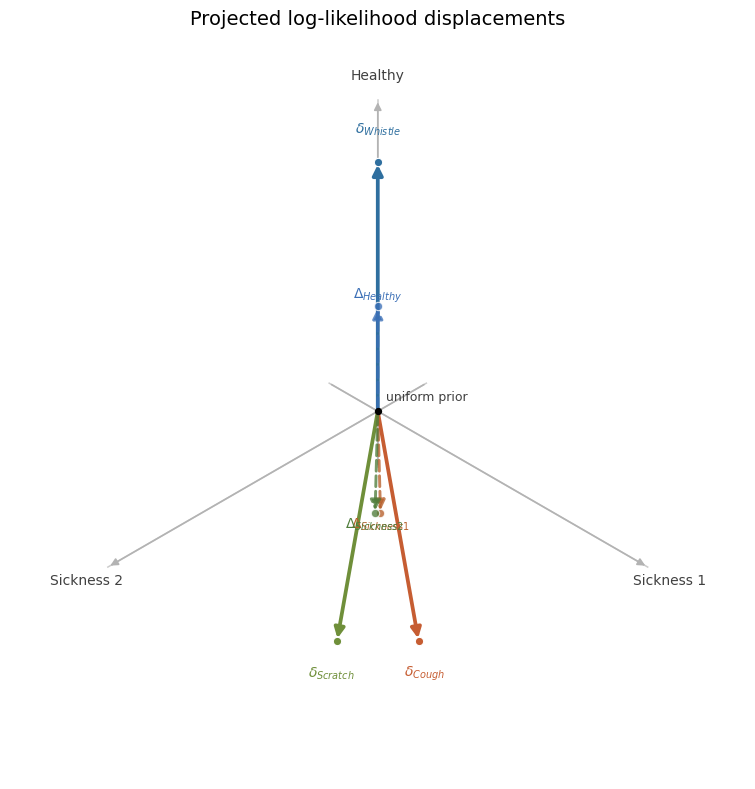

In [4]:
SHOW_EXPECTED_DISPLACEMENTS = True
SHOW_NUMERIC_LABELS = False

# Symmetric display frame. Since these three directions sum to zero, projected e_i
# land exactly on the three displayed state axes.
display_frame = np.array([
    [0.0, 1.0],
    [np.sqrt(3) / 2, -0.5],
    [-np.sqrt(3) / 2, -0.5],
])

signal_colors = ["#2f6f9f", "#c65d32", "#6f8f3a"]
state_colors = ["#3b6fb6", "#b65f2a", "#4f7d3b"]

def to_display(v):
    return project_common_offset(v) @ display_frame

def draw_state_axes(ax, radius):
    for state, direction in zip(STATES, display_frame):
        start = -0.18 * radius * direction
        end = radius * direction
        ax.plot([start[0], end[0]], [start[1], end[1]], color="0.80", lw=1.1, zorder=0)
        ax.annotate(
            "",
            xy=end,
            xytext=start,
            arrowprops=dict(arrowstyle="-|>", color="0.70", lw=1.2, mutation_scale=11),
            zorder=1,
        )
        label_pos = 1.08 * radius * direction
        ax.text(label_pos[0], label_pos[1], state, ha="center", va="center", fontsize=10, color="0.25")

def draw_vector(ax, xy, color, label, linestyle="-", linewidth=2.4, alpha=1.0, label_scale=1.06):
    ax.annotate(
        "",
        xy=xy,
        xytext=(0, 0),
        arrowprops=dict(
            arrowstyle="-|>",
            color=color,
            lw=linewidth,
            linestyle=linestyle,
            mutation_scale=15,
            alpha=alpha,
        ),
        zorder=3,
    )
    ax.scatter([xy[0]], [xy[1]], s=36, color=color, edgecolor="white", linewidth=0.8, zorder=4, alpha=alpha)
    norm = np.linalg.norm(xy)
    offset = np.array([0.02, 0.02]) if norm == 0 else (xy / norm) * 0.07
    ax.text(*(xy * label_scale + offset), label, color=color, fontsize=10, ha="center", va="center")

delta_xy = to_display(delta)
Delta_xy = to_display(Delta)

points_for_limits = [delta_xy]
if SHOW_EXPECTED_DISPLACEMENTS:
    points_for_limits.append(Delta_xy)
all_xy = np.vstack(points_for_limits)
radius = max(1.0, 1.25 * np.max(np.linalg.norm(all_xy, axis=1)))

fig, ax = plt.subplots(figsize=(8, 8))
draw_state_axes(ax, radius)

for signal, xy, color in zip(SIGNALS, delta_xy, signal_colors):
    label = f"$\\delta_{{{signal}}}$"
    if SHOW_NUMERIC_LABELS:
        label += f"\n{project_common_offset(delta[SIGNALS.index(signal)]).round(3)}"
    draw_vector(ax, xy, color=color, label=label, linewidth=2.7)

if SHOW_EXPECTED_DISPLACEMENTS:
    for state, xy, color in zip(STATES, Delta_xy, state_colors):
        draw_vector(ax, xy, color=color, label=f"$\\Delta_{{{state}}}$", linestyle="--", linewidth=2.1, alpha=0.78, label_scale=0.93)

ax.scatter([0], [0], color="black", s=18, zorder=5)
ax.text(0.03, 0.03, "uniform prior", color="0.25", fontsize=9, ha="left", va="bottom")

ax.set_title("Projected log-likelihood displacements", fontsize=14, pad=14)
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-radius * 1.18, radius * 1.18)
ax.set_ylim(-radius * 1.18, radius * 1.18)
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()
